## Imports

In [38]:
import warnings
warnings.filterwarnings("ignore")

In [39]:
import math
import os
import time
import requests
import pandas as pd
import json
import numpy as np
from pathlib import Path
from typing import Optional, Dict, List, Union
from unidecode import unidecode
import matplotlib.pyplot as plt

import pandas_gbq
from google.auth import default
from google.cloud import bigquery
from google.api_core.exceptions import NotFound

In [40]:
from funcoes_monitoramento import *
from funcoes_psi import *

In [41]:
from funcoes_monitoramento import compute_category_mix, _draw_rating_mix_panel

## Diretório e Configurações

In [42]:
BASE_DIR = Path("data")
RAW_DIR = BASE_DIR / "raw"
TRUSTED_DIR = BASE_DIR / "trusted"
ANALYTICS_DIR = BASE_DIR / "analytics"

for path in [RAW_DIR, TRUSTED_DIR, ANALYTICS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

In [43]:
MODEL_ORDER = [
    "BLEND4",
    "BLEND3",
    "BLEND_REGRESSAO_2026",
    # "BVS_CUSTOM",
    # "HVA3",
    # "HVA4",
]

MODEL_ORDER_GRAPH = ["BLEND4", "BLEND3"]

MODEL_COL = "bureau_nm_ajust"
RATING_COL = "rating_score_ds"

MODEL_COLOR_MAP = {
    "BLEND4": "#3B82F6",
    "BLEND3": "#94A3B8",
    "BLEND_REGRESSAO_2026": "#8B5CF6",
    # "BVS_CUSTOM": "#06B6D4",
    # "HVA3": "#14B8A6",
    # "HVA4": "#6366F1",
}

RATING_ORDER = ["A", "B", "C", "D", "E", "N/I"]
RATING_COLOR_MAP = {
    "A": "#7DD3FC",
    "B": "#5EEAD4",
    "C": "#93C5FD",
    "D": "#818CF8",
    "E": "#334155",
    "N/I": "#CBD5E1",
}
RATING_TEXT_COLOR_MAP = {
    "A": "white", "B": "white", "C": "black",
    "D": "white", "E": "white", "N/I": "black",
}

PRE_ANALISE_ORDER = ["APROVAR", "DERIVAR", "REPROVAR"]
PRE_ANALISE_COLOR_MAP = {
    "APROVAR": "#9ECACA",
    "DERIVAR": "#B5BFE8",
    "REPROVAR": "#9AA5B1",
}
PRE_ANALISE_TEXT_COLOR_MAP = {
    "APROVAR": "white", "DERIVAR": "white", "REPROVAR": "white",
}

FUNNEL_BINARY_STEPS = [
    "is_elegivel",
    "is_iniciada",
    "is_enviada",
    "is_aprovada",
    "is_ativada",
]

BLEND_FUNNEL_METRICS = [
    "elegivel_pct_total",
    "iniciada_pct_elegivel",
    "enviada_pct_iniciada",
    "aprovada_pct_enviada",
    "ativada_pct_aprovada",
    "conversao_pct_total",
]

In [44]:
RATING_DS_POL_ORDER = {
    "A+":"1.A+",
    "A":"2.A",
    "B+":"3.B+",
    "B":"4.B",
    "C":"5.C",
    "D+":"6.D+",
    "D":"7.D",
    "E":"8.E",
    "E-BVS":"9.E-BVS",
}

RATING_GROUP_ORDER = {
    "1.A+": "A",
    "2.A": "A",
    "3.B+": "B",
    "4.B": "B",
    "5.C": "C",
    "6.D+": "D",
    "7.D": "D",
    "8.E": "E",
    "9.E-BVS": "E",
}

RATING_DS_POL_COLOR_MAP = {
    "1.A+":   "#22D3EE",  # best
    "2.A":    "#38BDF8",
    "3.B+":   "#2DD4BF",
    "4.B":    "#6EE7B7",
    "5.C":    "#93C5FD",
    "6.D+":   "#A5B4FC",
    "7.D":    "#818CF8",
    "8.E":    "#475569",
    "9.E-BVS": "#1E293B",
}

RATING_DS_POL_TEXT_COLOR_MAP = {
    "1.A+":    "black",
    "2.A":     "black",
    "3.B+":    "black",
    "4.B":     "black",
    "5.C":     "black",
    "6.D+":    "white",
    "7.D":     "white",
    "8.E":     "white",
    "9.E-BVS": "white",
}

In [45]:
WINDOW_DAYS = 8
WINDOW_WEEKS = 6

## Base: Blend4 em Produção

In [ ]:
df_raw = pd.read_csv(ANALYTICS_DIR / "df_funil_blend4.csv", low_memory=False)
df_raw["requested_at"] = pd.to_datetime(df_raw["requested_at"])

df_raw["rating_score_ds"] = df_raw["rating_score_ds"].replace(RATING_DS_POL_ORDER)
df_raw["rating_score_group"] = df_raw["rating_score_ds"].replace(RATING_GROUP_ORDER)

for col in ["iniciada_at", "enviada_at", "activated_at", "cancelled_at"]:
    if col in df_raw.columns:
        df_raw[col] = pd.to_datetime(df_raw[col], errors="coerce")

# Flags padronizadas do funil blend
df = prepare_blend_funnel_columns(df_raw)
df = prepare_week_columns(df, "requested_at")
df = df[df[MODEL_COL] != "-1"].copy()

# Produção real: evita duplicar contrato entre BLEND4 (simulado) e BLEND3_3 (prod)
df_prod = df[df[MODEL_COL] == df["bureau_nm_ajust"]].copy()

print(f"Volume total (simulação): {len(df):,}")
print(f"Contratos únicos: {df['contract_id'].nunique():,}")
print(f"Volume produção: {len(df_prod):,}")
print(f"Período: {df['requested_at'].min()} → {df['requested_at'].max()}")
df.head()

Volume total (simulação): 37,604
Contratos únicos: 37,604
Volume produção: 37,589
Período: 2026-07-01 00:00:00 → 2026-07-09 00:00:00


,contract_id,dt_lead,requested_at,iniciada_at,enviada_at,activated_at,cancelled_at,dt_saida,tipo_contrato,product_nm,...,rating_score_group,is_elegivel,is_iniciada,is_enviada,is_aprovada,is_ativada,week_start,year_week,year,week_of_year
0,4323309,2026-07-02,2026-07-02,NaT,NaT,NaT,2026-07-02,NaN,PF,NaN,...,E,0,0,0,0,0,2026-06-28,2026-06-28,2026,27
1,4322739,2026-07-02,2026-07-02,NaT,NaT,NaT,2026-07-02,NaN,PF,NaN,...,E,0,0,0,0,0,2026-06-28,2026-06-28,2026,27
2,4323484,2026-07-02,2026-07-02,NaT,NaT,NaT,2026-07-02,NaN,PF,NaN,...,E,0,0,0,0,0,2026-06-28,2026-06-28,2026,27
3,4326952,2026-07-02,2026-07-02,NaT,NaT,NaT,2026-07-02,NaN,PF,NaN,...,E,0,0,0,0,0,2026-06-28,2026-06-28,2026,27
4,4323428,2026-07-02,2026-07-02,NaT,NaT,NaT,2026-07-02,NaN,PF,NaN,...,E,0,0,0,0,0,2026-06-28,2026-06-28,2026,27


In [47]:
df_uniprop = df[df["qtd_proponentes"] == 1].copy()

df_multprop = df[df["qtd_proponentes"] >= 2].copy()

## Diário e Semanal

In [48]:
df_daily = filter_monitoring_window(
    df_uniprop,
    n_days=WINDOW_DAYS,
    mode="rolling",
)
df_daily_prod = filter_monitoring_window(
    df_prod,
    n_days=WINDOW_DAYS,
    mode="rolling",
)

print(f"Diário simulação: {df_daily['requested_at'].min()} → {df_daily['requested_at'].max()} | n={len(df_daily):,}")
print(f"Diário produção: {df_daily_prod['requested_at'].min()} → {df_daily_prod['requested_at'].max()} | n={len(df_daily_prod):,}")

Diário simulação: 2026-07-02 00:00:00 → 2026-07-09 00:00:00 | n=30,813
Diário produção: 2026-07-02 00:00:00 → 2026-07-09 00:00:00 | n=32,016


In [49]:
df_weekly = filter_monitoring_week_window(
    df_uniprop,
    n_weeks=WINDOW_WEEKS,
    mode="rolling",
)
df_weekly_prod = filter_monitoring_week_window(
    df_prod,
    n_weeks=WINDOW_WEEKS,
    mode="rolling",
)

print(f"Semanal simulação: {df_weekly['requested_at'].min()} → {df_weekly['requested_at'].max()} | n={len(df_weekly):,}")
print(f"Semanal produção: {df_weekly_prod['requested_at'].min()} → {df_weekly_prod['requested_at'].max()} | n={len(df_weekly_prod):,}")

Semanal simulação: 2026-07-01 00:00:00 → 2026-07-09 00:00:00 | n=36,187
Semanal produção: 2026-07-01 00:00:00 → 2026-07-09 00:00:00 | n=37,589


## Multiproponente vs. Uniproponente

In [50]:
PROPONENTE_ORDER = ["Uniproponente", "Multiproponente"]

PROPONENTE_COLOR_MAP = {
    "Uniproponente": "#94A3B8",   # slate
    "Multiproponente": "#3B82F6", # blue
}

PROPONENTE_TEXT_COLOR_MAP = {
    "Uniproponente": "white",
    "Multiproponente": "white",
}

def add_tipo_proponente(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["tipo_proponente"] = np.where(
        out["qtd_proponentes"] == 1,
        "Uniproponente",
        "Multiproponente",
    )
    return out

# Use df (BLEND4 + income > 0) ou df_raw (base completa)
df_prop = add_tipo_proponente(df_raw)

print(df_prop["tipo_proponente"].value_counts(normalize=True).mul(100).round(2))
print(df_prop["tipo_proponente"].value_counts())

tipo_proponente
Uniproponente      96.23
Multiproponente     3.77
Name: proportion, dtype: float64
tipo_proponente
Uniproponente      36187
Multiproponente     1417
Name: count, dtype: int64


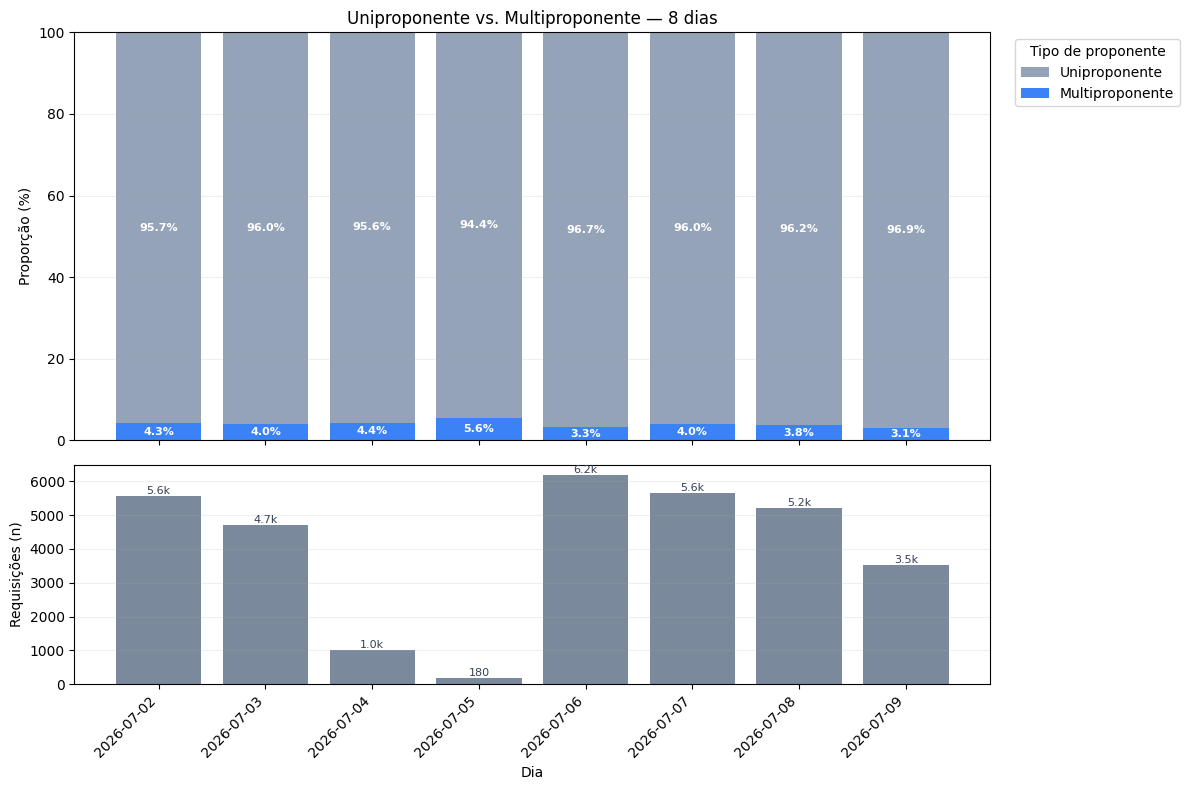

In [51]:
WINDOW_DAYS = 8

df_daily_prop = filter_monitoring_window(
    df_prop,
    n_days=WINDOW_DAYS,
    mode="rolling",
)

plot_daily_mix(
    df_daily_prop,
    category_col="tipo_proponente",
    title=f"Uniproponente vs. Multiproponente — {WINDOW_DAYS} dias",
    category_order=PROPONENTE_ORDER,
    color_map=PROPONENTE_COLOR_MAP,
    text_color_map=PROPONENTE_TEXT_COLOR_MAP,
    reverse_stack=True,
    legend_title="Tipo de proponente",
    min_label_pct=1.0,
)

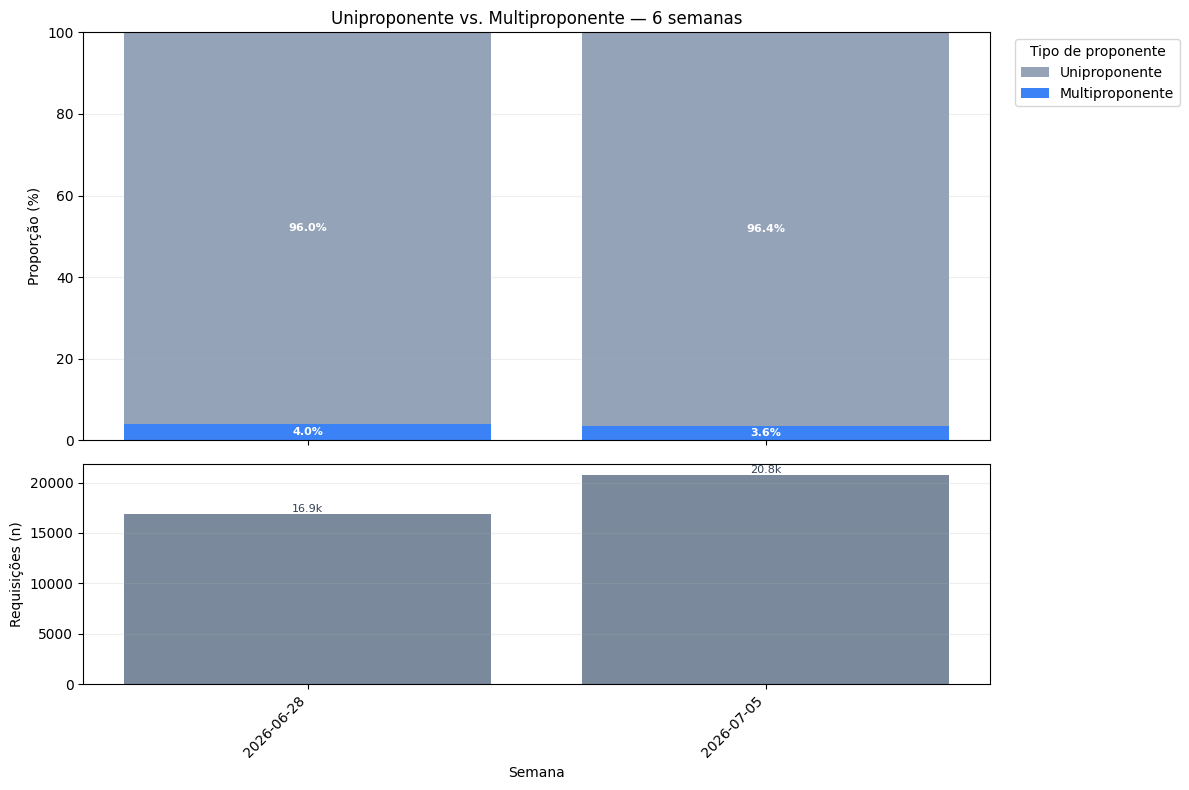

In [52]:
WINDOW_WEEKS = 6

df_weekly_prop = filter_monitoring_week_window(
    df_prop,
    n_weeks=WINDOW_WEEKS,
    mode="rolling",
)

plot_weekly_mix(
    df_weekly_prop,
    category_col="tipo_proponente",
    title=f"Uniproponente vs. Multiproponente — {WINDOW_WEEKS} semanas",
    category_order=PROPONENTE_ORDER,
    color_map=PROPONENTE_COLOR_MAP,
    text_color_map=PROPONENTE_TEXT_COLOR_MAP,
    reverse_stack=True,
    legend_title="Tipo de proponente",
    min_label_pct=1.0,
)

# Uniproponentes

## Mix de Modelos Diário e Semanal

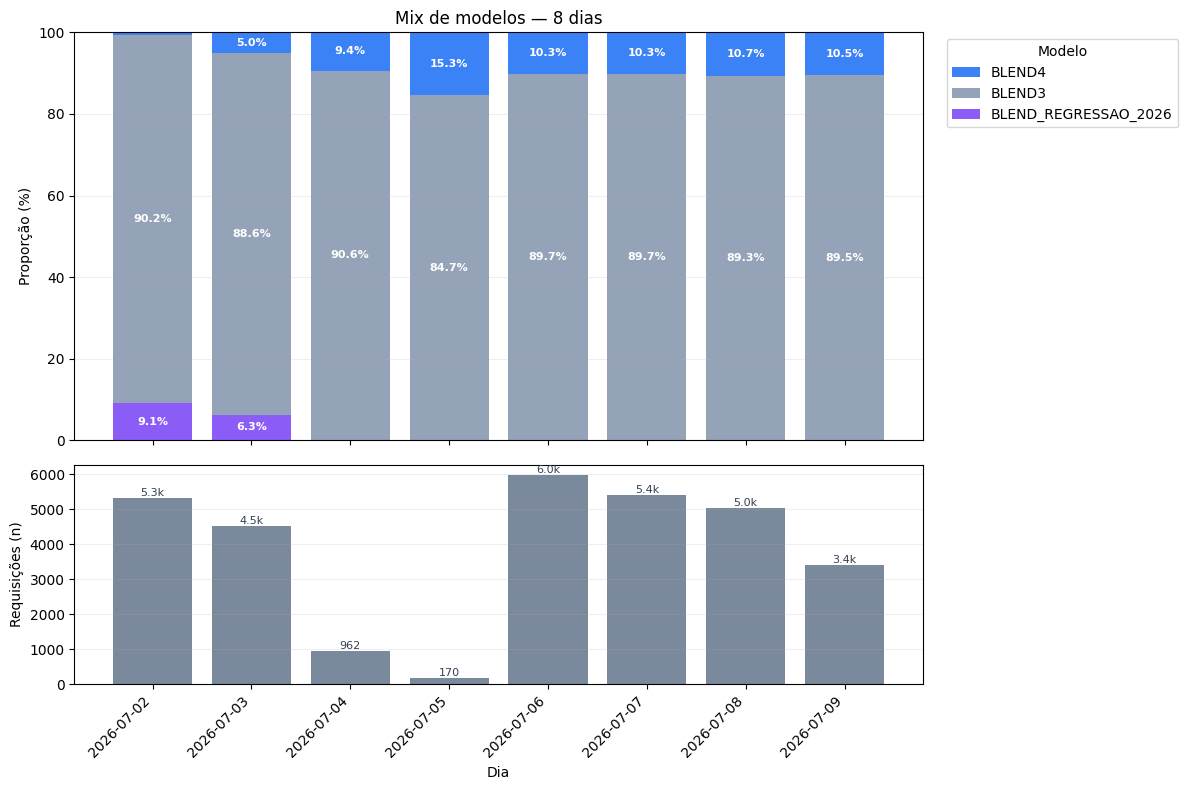

In [53]:
plot_daily_mix(
    df_daily,
    category_col=MODEL_COL,
    title=f"Mix de modelos — {WINDOW_DAYS} dias",
    category_order=MODEL_ORDER,
    color_map=MODEL_COLOR_MAP,
    reverse_stack=True,
    legend_title="Modelo",
    min_label_pct=3.0,
)

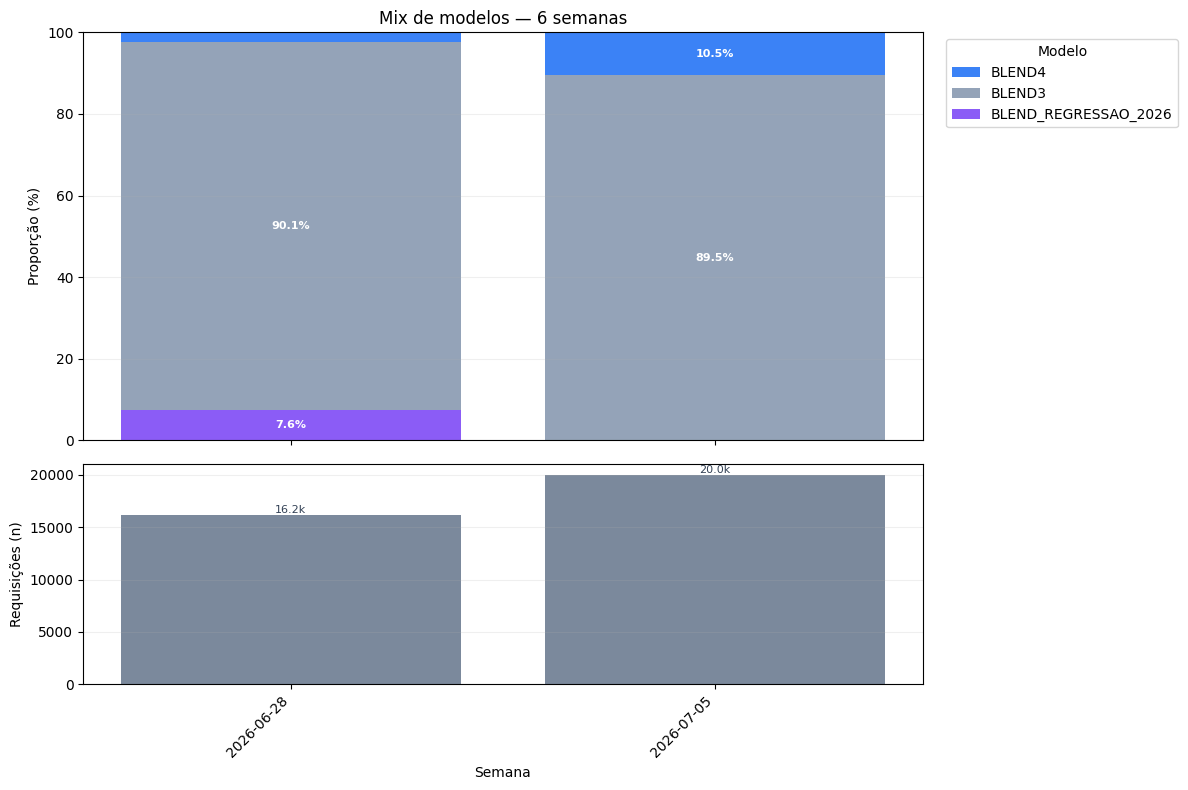

In [54]:
plot_weekly_mix(
    df_weekly,
    category_col=MODEL_COL,
    title=f"Mix de modelos — {WINDOW_WEEKS} semanas",
    category_order=MODEL_ORDER,
    color_map=MODEL_COLOR_MAP,
    reverse_stack=True,
    legend_title="Modelo",
    min_label_pct=3.0,
)

## Pré-Análise

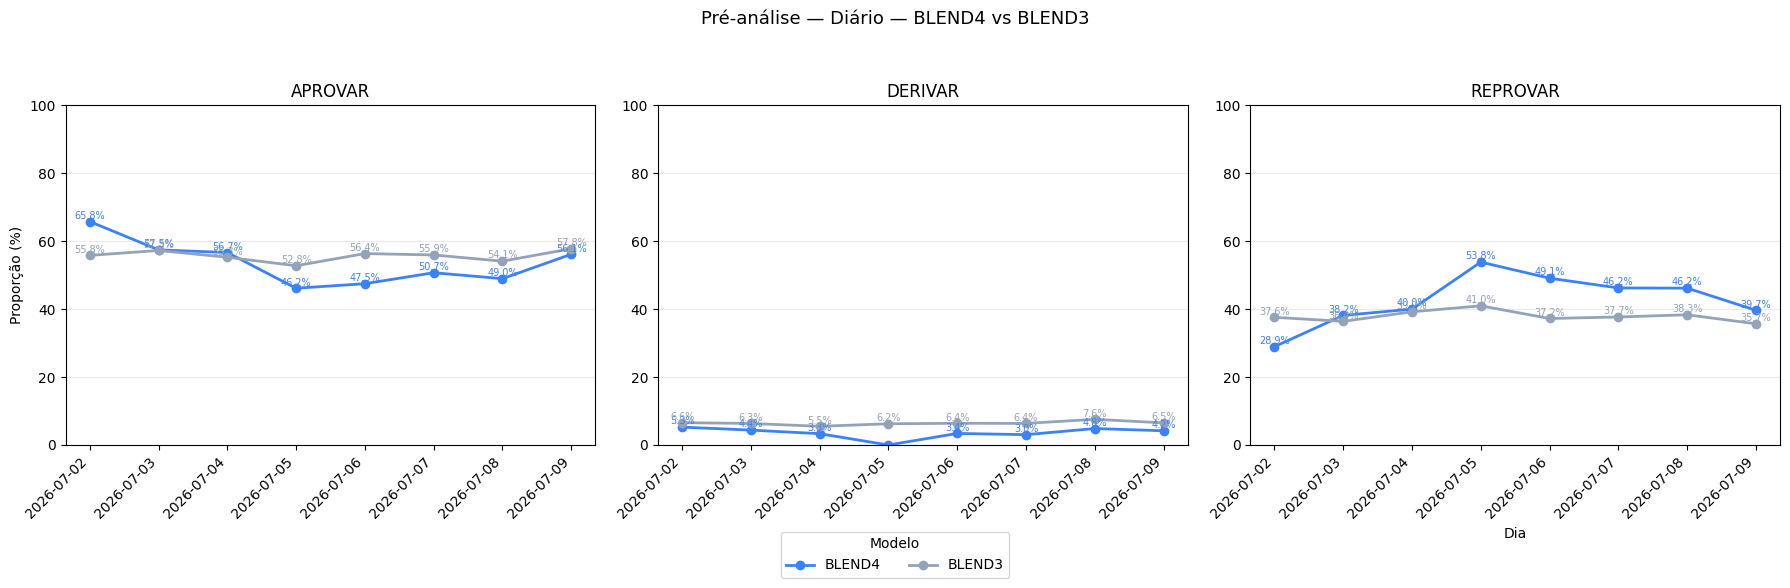

In [55]:
plot_pre_analysis_comparison(
    df_daily,
    models=MODEL_ORDER_GRAPH,
    time_grain="day",
    model_col=MODEL_COL,
    color_map=MODEL_COLOR_MAP,
    suptitle="Pré-análise — Diário — BLEND4 vs BLEND3",
    ylim=(0, 100),
)

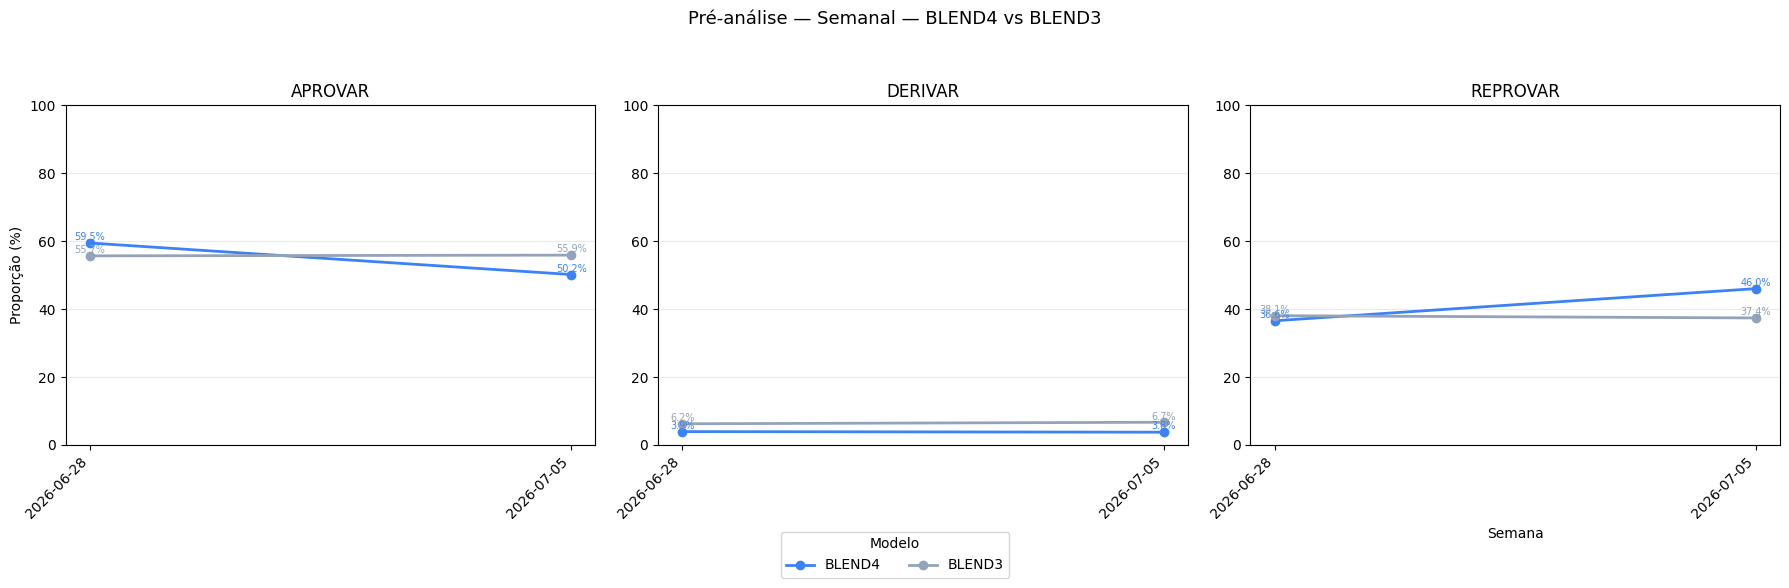

In [56]:
plot_pre_analysis_comparison(
    df_weekly,
    models=MODEL_ORDER_GRAPH,
    time_grain="week",
    model_col=MODEL_COL,
    color_map=MODEL_COLOR_MAP,
    suptitle="Pré-análise — Semanal — BLEND4 vs BLEND3",
    ylim=(0, 100),
)

## Funil

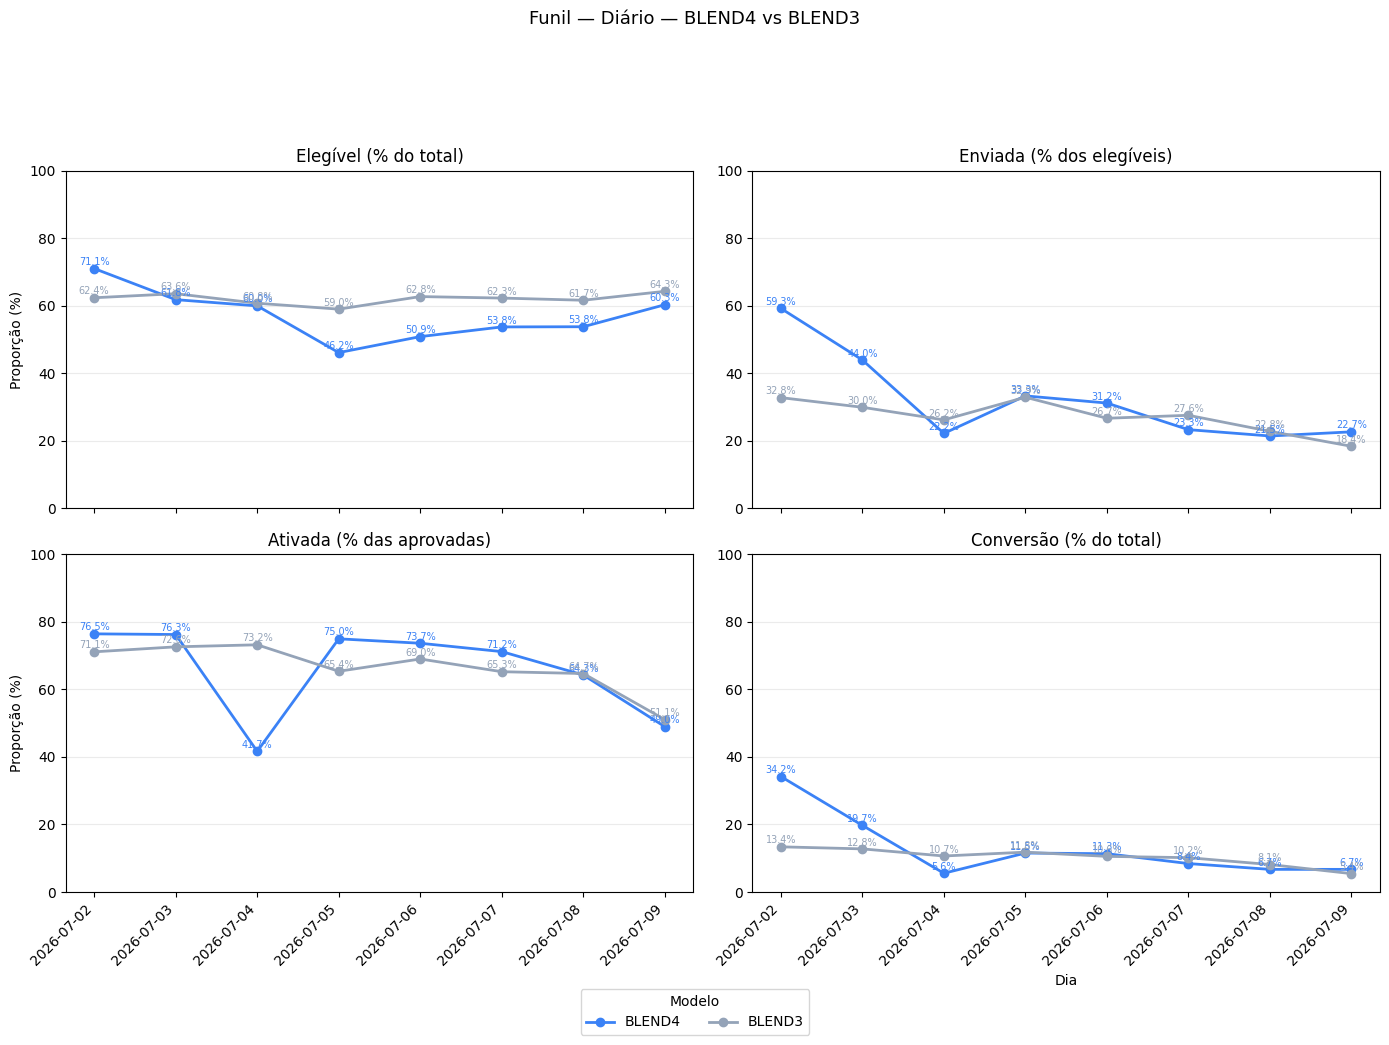

In [57]:
plot_funnel_metric_comparison(
    df_daily,
    models=MODEL_ORDER_GRAPH,
    metrics=FUNNEL_COMPARE_METRICS,
    time_grain="day",
    model_col=MODEL_COL,
    color_map=MODEL_COLOR_MAP,
    suptitle="Funil — Diário — BLEND4 vs BLEND3",
    ylim=(0, 100),
)

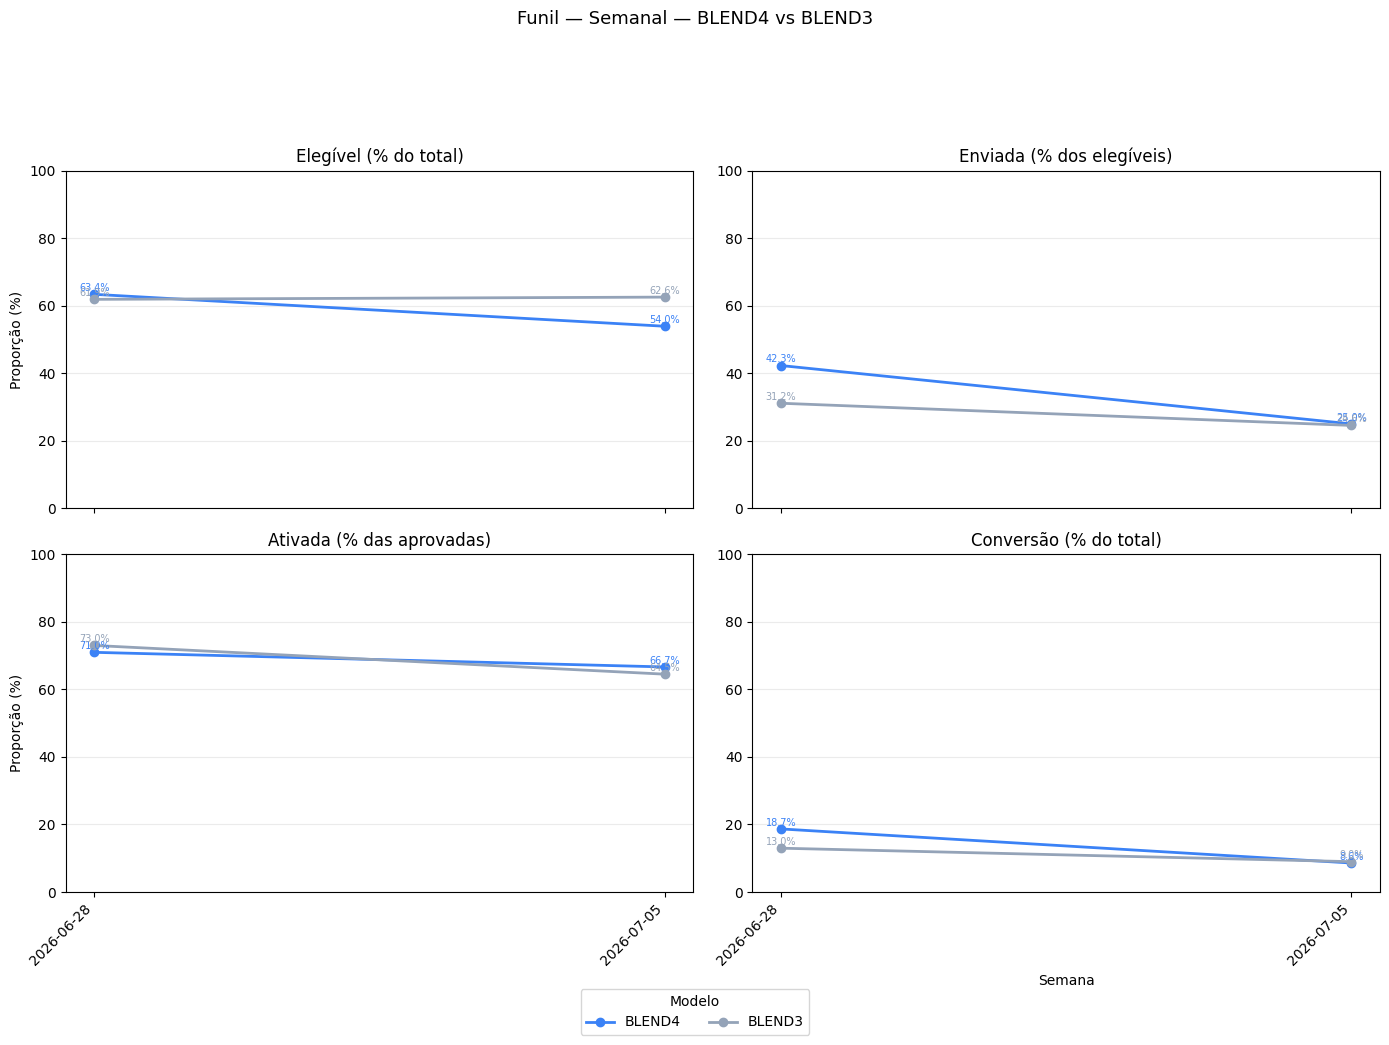

In [58]:
plot_funnel_metric_comparison(
    df_weekly,
    models=MODEL_ORDER_GRAPH,
    metrics=FUNNEL_COMPARE_METRICS,
    time_grain="week",
    model_col=MODEL_COL,
    color_map=MODEL_COLOR_MAP,
    suptitle="Funil — Semanal — BLEND4 vs BLEND3",
)

## Tabela Resumo

In [59]:
tabela_counts = build_blend_comparison_summary_table_counts(
    df_weekly,
    models=MODEL_ORDER_GRAPH,
    model_col=MODEL_COL,
    time_grain="week",
)

def color_negative_diff_counts(row):
    val = row.get(("diff_conversao", ""))
    if pd.notna(val) and val < 0:
        return ["background-color: #f44336"] * len(row)
    return [""] * len(row)

display(
    tabela_counts.style
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "center")]},
        {"selector": "td", "props": [("text-align", "center")]},
    ])
    .format("{:,.0f}")  # inteiros com separador de milhar
    # .format("{:+.2f}%", subset=[("diff_conversao", "")])
    # .apply(color_negative_diff_counts, axis=1)
)

In [60]:
tabela_pct = build_blend_comparison_summary_table(
    df_weekly,
    models=MODEL_ORDER_GRAPH,
    model_col=MODEL_COL,
    time_grain="week",
    baseline_model="BLEND3",
    challenger_model="BLEND4",
)

def color_negative_diff_pct(row):
    val = row.get(("diff_conversao", ""))
    if pd.notna(val) and val < 0:
        return ["background-color: #f44336"] * len(row)
    return [""] * len(row)

pct_cols = [
    ("mix", "BLEND4"),
    ("%_elegivel", "BLEND4"),
    ("%_enviada_elegivel", "BLEND4"),
    ("%_ativada", "BLEND4"),
    ("%_conversao", "BLEND4"),
    ("mix", "BLEND3"),
    ("%_elegivel", "BLEND3"),
    ("%_enviada_elegivel", "BLEND3"),
    ("%_ativada", "BLEND3"),
    ("%_conversao", "BLEND3"),
]

display(
    tabela_pct.style
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "center")]},
        {"selector": "td", "props": [("text-align", "center")]},
    ])
    .format("{:.2%}", subset=pct_cols, na_rep="-")
    .format(
        lambda v: f"{v * 100:+.2f} pp" if pd.notna(v) else "-",
        subset=[("diff_conversao", "")],
    )
    .apply(color_negative_diff_pct, axis=1)
)

## Mix de Rating por Modelo: Blend 4 vs. Blend3

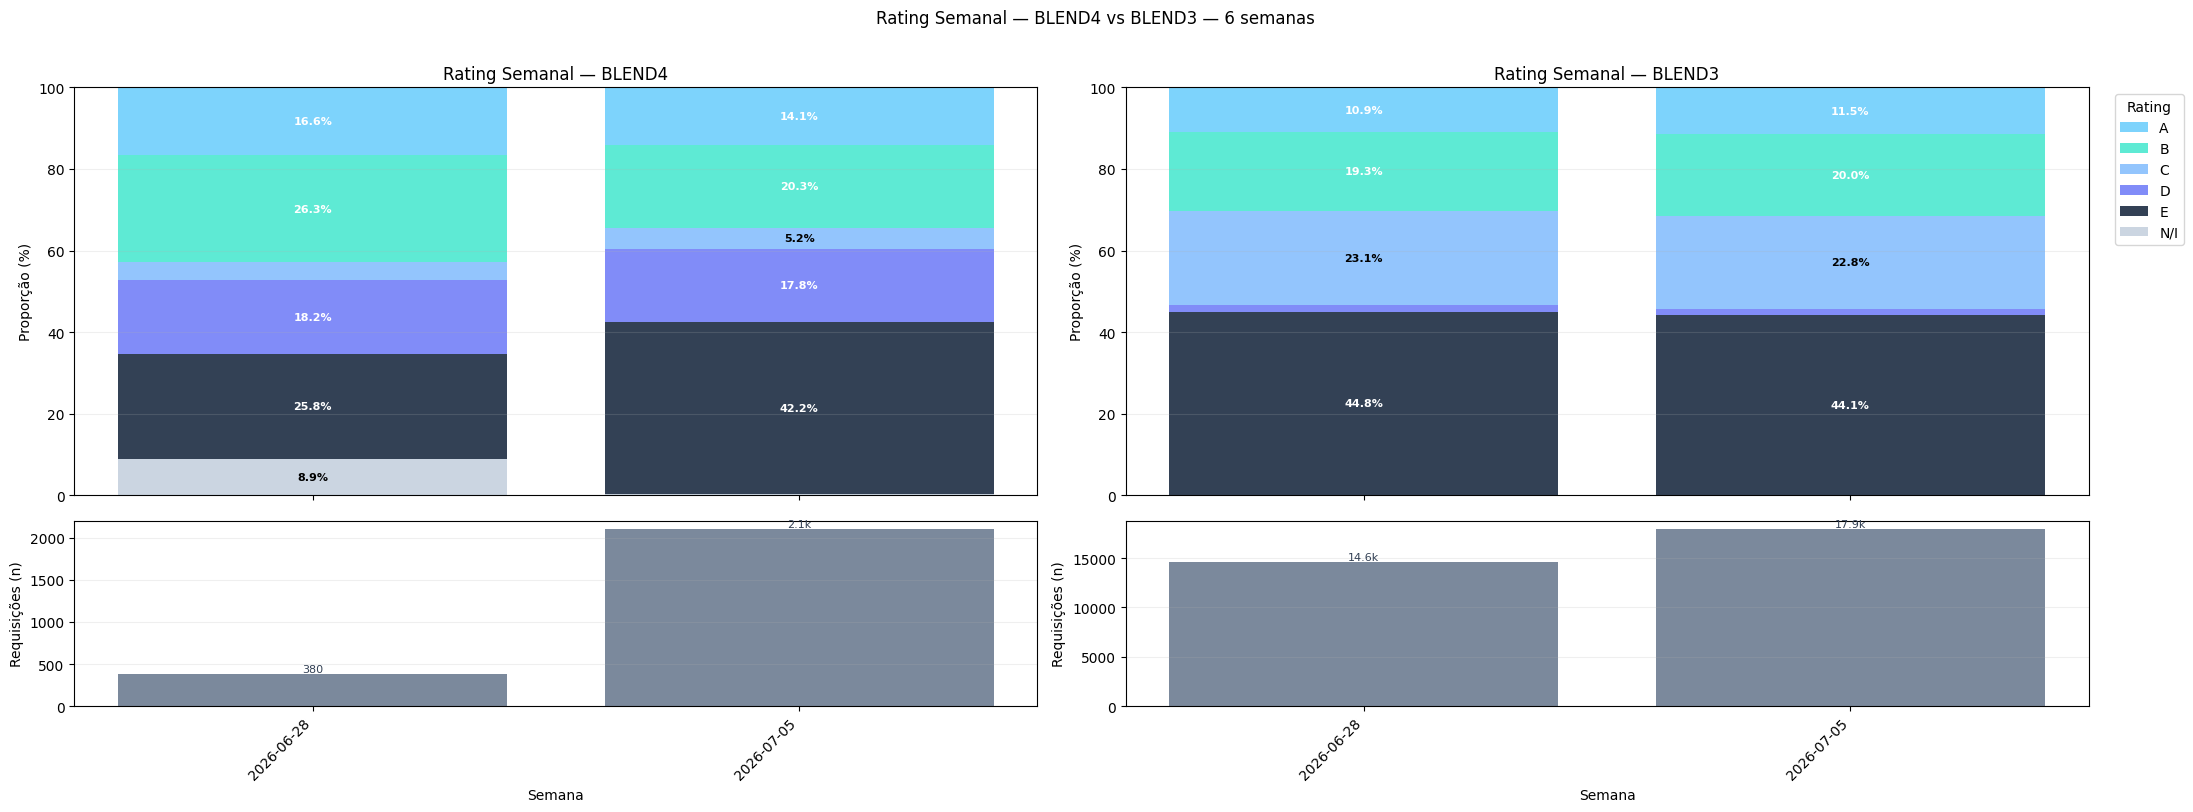

In [61]:
models_data = []
for model in MODEL_ORDER_GRAPH:
    df_model = df_weekly[df_weekly[MODEL_COL] == model]
    if df_model.empty:
        continue

    pct_df, _, volume = compute_category_mix(
        df_model,
        category_col="rating_score_group",
        time_grain="week",
    )
    models_data.append((model, pct_df, volume))

if not models_data:
    print("[skip] Sem dados para rating diário comparável")
else:
    all_periods = sorted(set().union(*[pct.index for _, pct, _ in models_data]))
    aligned = [
        (
            model,
            pct_df.reindex(all_periods, fill_value=0),
            volume.reindex(all_periods, fill_value=0),
        )
        for model, pct_df, volume in models_data
    ]

    n = len(aligned)
    fig, axes = plt.subplots(
        2, n,
        figsize=(11 * n, 8),
        sharex="col",
        gridspec_kw={"height_ratios": [2.2, 1]},
    )
    if n == 1:
        axes = axes.reshape(2, 1)

    for col, (model, pct_df, volume) in enumerate(aligned):
        _draw_rating_mix_panel(
            axes[0, col],
            axes[1, col],
            pct_df,
            volume,
            panel_title=f"Rating Semanal — {model}",
            xlabel="Semana",
            category_order=RATING_ORDER,
            color_map=RATING_COLOR_MAP,
            text_color_map=RATING_TEXT_COLOR_MAP,
            reverse_stack=True,
            min_label_pct=5.0,
            show_legend=(col == n - 1),  # legenda só no painel da direita
            legend_title="Rating",
        )

    fig.suptitle(
        f"Rating Semanal — BLEND4 vs BLEND3 — {WINDOW_WEEKS} semanas",
        y=1.01,
        fontsize=12,
    )
    plt.tight_layout()
    plt.show()

## Rating Política - Esperado vs. Produção

In [62]:
RATING_CL_POL_COL = "rating_score_ds"

RATING_CL_POL_ORDER = [
    "1.A+",
    "2.A",
    "3.B+",
    "4.B",
    "5.C",
    "6.D+",
    "7.D",
    "8.E",
    "9.E-BVS",
    "N/I"
]

RATING_CL_POL_COLOR_MAP = {
    "1.A+":   "#22D3EE",  # best
    "2.A":    "#38BDF8",
    "3.B+":   "#2DD4BF",
    "4.B":    "#6EE7B7",
    "5.C":    "#93C5FD",
    "6.D+":   "#A5B4FC",
    "7.D":    "#818CF8",
    "8.E":    "#475569",
    "9.E-BVS": "#1E293B",
    "N/I":    "#4f6d9e",
}

RATING_CL_POL_TEXT_COLOR_MAP = {
    "1.A+":    "black",
    "2.A":     "black",
    "3.B+":    "black",
    "4.B":     "black",
    "5.C":     "black",
    "6.D+":    "white",
    "7.D":     "white",
    "8.E":     "white",
    "9.E-BVS": "white",
    "N/I":    "white",
}

In [63]:
df_rt_dev = pd.read_csv(ANALYTICS_DIR/"dev_rating_pol_blend4.csv").rename(columns={"9.E.BVS": "9.E-BVS"})
df_rt_dev

,safra,1.A+,2.A,3.B+,4.B,5.C,6.D+,7.D,8.E,9.E-BVS,volume
0,2024-09,7.397561,15.175992,14.856471,13.846783,6.451778,6.168043,11.625470,16.776156,7.701746,39121
1,2024-10,7.330487,14.833114,14.645324,13.947821,6.398247,6.053967,11.490912,17.573942,7.726185,44731
2,2024-11,7.427314,14.752131,14.459639,13.962151,6.404840,6.192345,11.267218,17.967051,7.567311,40001
3,2024-12,7.603344,14.442638,13.646075,13.722712,6.444496,6.223874,11.314445,18.704134,7.898281,43060
4,2025-01,7.351552,13.820624,12.712479,12.695966,6.083790,6.143417,11.877700,19.528304,9.786168,109011
5,2025-02,7.398159,13.522902,12.760880,12.659523,6.163443,6.111843,12.239351,19.707538,9.436361,108527
6,2025-03,6.804974,12.575767,11.831115,11.848820,6.090525,6.005124,12.459122,22.019830,10.364723,96018
7,2025-04,6.370160,11.931199,11.890075,11.751280,5.885921,6.062756,12.445253,23.132441,10.530915,97266
8,2025-05,5.972157,11.638604,11.378045,11.663061,5.819772,5.920421,12.697771,24.315681,10.594488,106310
9,2025-06,6.270259,12.297618,11.863517,11.505732,5.989611,5.832875,12.034203,23.320833,10.885353,121861


In [64]:
model = "BLEND4"
safra_ref = "2025-08"
min_label_pct = 1.0

# --- Esquerda: proporções esperadas (dev) ---
row = df_rt_dev.loc[df_rt_dev["safra"] == safra_ref]
if row.empty:
    raise ValueError(f"Safra {safra_ref} não encontrada em df_rt_dev")

pct_expected = row.set_index("safra").reindex(columns=RATING_CL_POL_ORDER, fill_value=0)
vol_expected = row.set_index("safra")["volume"]

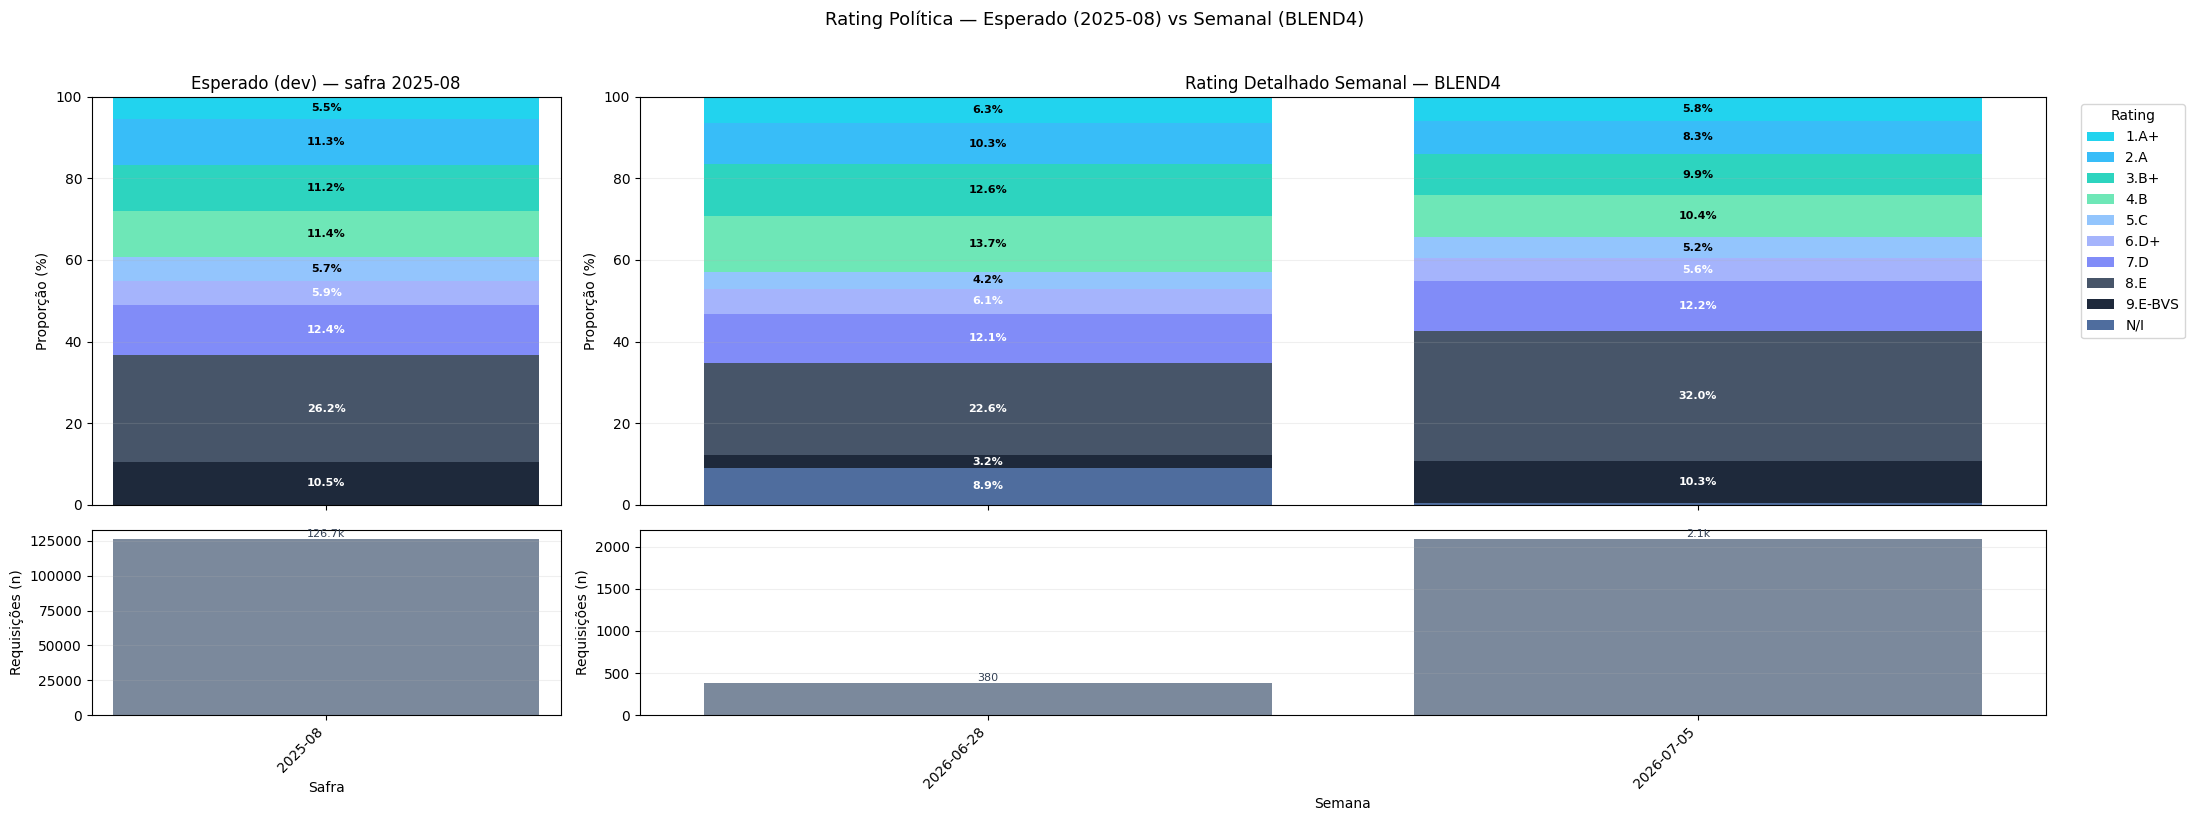

In [65]:
df_model = df_weekly[df_weekly["bureau_nm_ajust"] == model]

pct_prod, _, vol_prod = compute_category_mix(
    df_model,
    category_col=RATING_CL_POL_COL,
    time_grain="week",
)

if pct_prod.empty:
    print(f"[skip] Sem dados semanais para: {model}")
else:
    fig, axes = plt.subplots(
        2, 2,
        figsize=(22, 8),
        sharex="col",
        gridspec_kw={
            "height_ratios": [2.2, 1],
            "width_ratios": [1, 3],  # mais espaço para as semanas à direita
        },
    )

    _draw_rating_mix_panel(
        axes[0, 0], axes[1, 0],
        pct_expected,
        vol_expected,
        panel_title=f"Esperado (dev) — safra {safra_ref}",
        xlabel="Safra",
        category_order=RATING_CL_POL_ORDER,
        color_map=RATING_CL_POL_COLOR_MAP,
        text_color_map=RATING_CL_POL_TEXT_COLOR_MAP,
        reverse_stack=True,
        min_label_pct=min_label_pct,
        show_legend=False,
        legend_title="Rating",
    )

    _draw_rating_mix_panel(
        axes[0, 1], axes[1, 1],
        pct_prod,
        vol_prod,
        panel_title=f"Rating Detalhado Semanal — {model}",
        xlabel="Semana",
        category_order=RATING_CL_POL_ORDER,
        color_map=RATING_CL_POL_COLOR_MAP,
        text_color_map=RATING_CL_POL_TEXT_COLOR_MAP,
        reverse_stack=True,
        min_label_pct=min_label_pct,
        show_legend=True,
        legend_title="Rating",
    )

    fig.suptitle(
        f"Rating Política — Esperado ({safra_ref}) vs Semanal ({model})",
        y=1.02,
        fontsize=13,
    )
    plt.tight_layout()
    plt.show()

## Funil por Rating

In [66]:
RATING_COL = "rating_score_group"

In [67]:
MIN_VOLUME_WEEKLY = 100
RATINGS_TO_PLOT = ["A", "B", "C", "D", "E", "N/I"]

MODEL_LABELS = {
    "BLEND3": "Blend 3",
    "BLEND4": "Blend 4",
}

METRICS = {
    "elegivel_pct_total": "Elegível (%)",
    "enviada_pct_elegivel": "Envio (%)",
    "conversao_pct_total": "Conversão (%)",
}

funnel_long = build_funnel_by_rating_table(
    df_weekly,
    models=MODEL_ORDER_GRAPH,
    ratings=RATINGS_TO_PLOT,
    time_grain="week",
    model_col=MODEL_COL,
    rating_col=RATING_COL,
    min_volume_per_model=MIN_VOLUME_WEEKLY,
)

for metric_col, metric_label in METRICS.items():
    print(f"\n=== {metric_label} — Semanal — por rating ===")

    tabela = funnel_long.pivot_table(
        index="period",
        columns=["model", "rating"],
        values=metric_col,
        aggfunc="first",
    ).sort_index()

    # Renomeia colunas para ficar legível
    tabela.columns = pd.MultiIndex.from_tuples([
        (MODEL_LABELS.get(model, model), f"Rating {rating}")
        for model, rating in tabela.columns
    ])

    display(
        tabela.style
        .format("{:.1f}", na_rep="—")
        .set_table_styles([
            {"selector": "th", "props": [("text-align", "center")]},
            {"selector": "td", "props": [("text-align", "center")]},
        ])
    )


=== Elegível (%) — Semanal — por rating ===



=== Envio (%) — Semanal — por rating ===



=== Conversão (%) — Semanal — por rating ===


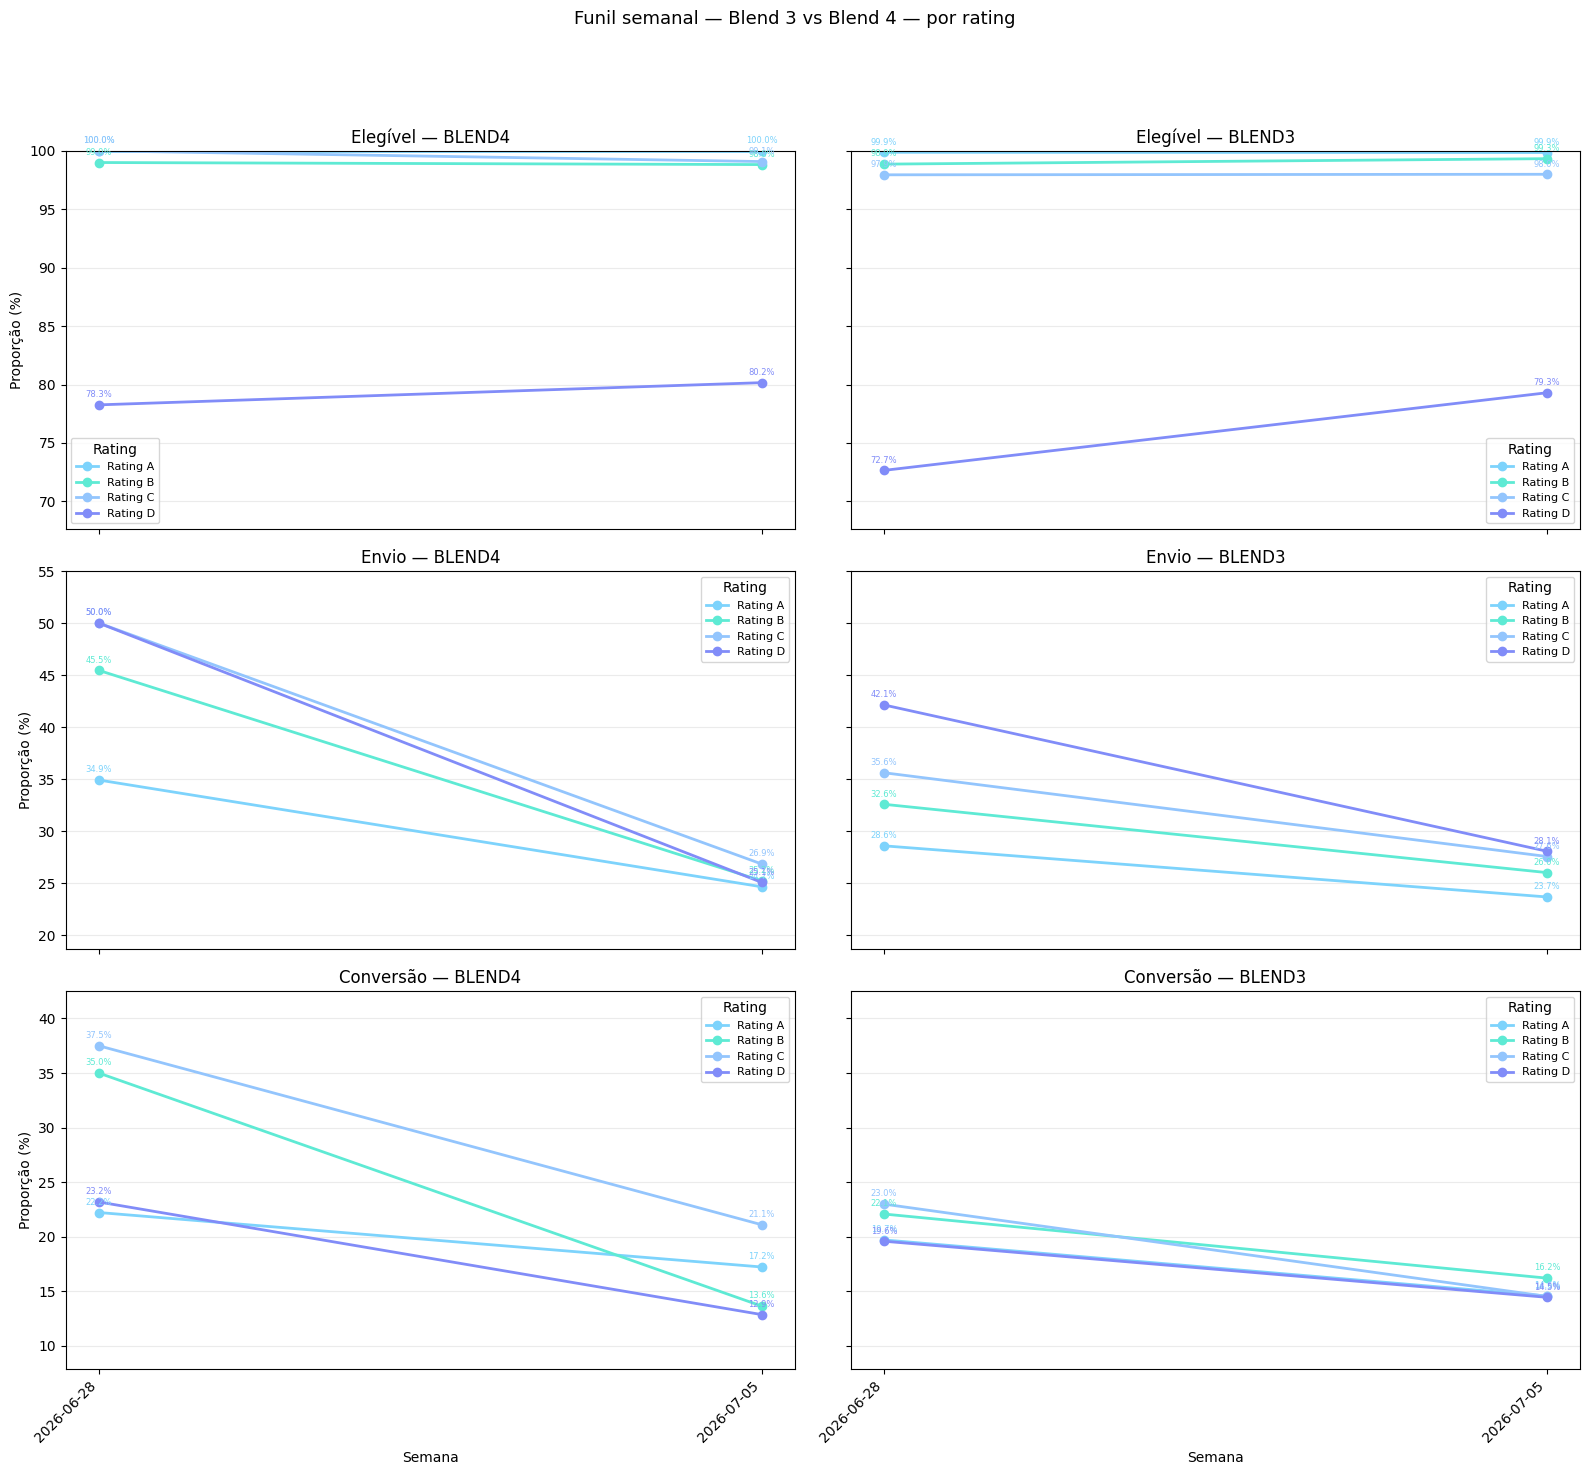

In [68]:

RATINGS_TO_PLOT = ["A", "B", "C", "D"]
plot_funnel_metrics_by_rating_side_by_side(
    df_weekly,
    models=MODEL_ORDER_GRAPH,
    ratings=RATINGS_TO_PLOT,
    time_grain="week",
    model_col=MODEL_COL,
    rating_col=RATING_COL,
    # min_volume_per_model=MIN_VOLUME_WEEKLY,
    ylim=None,              # auto por linha
    auto_ylim_pad=5.0,      # margem acima/abaixo dos dados
    show_labels=True,
    suptitle="Funil semanal — Blend 3 vs Blend 4 — por rating",
)

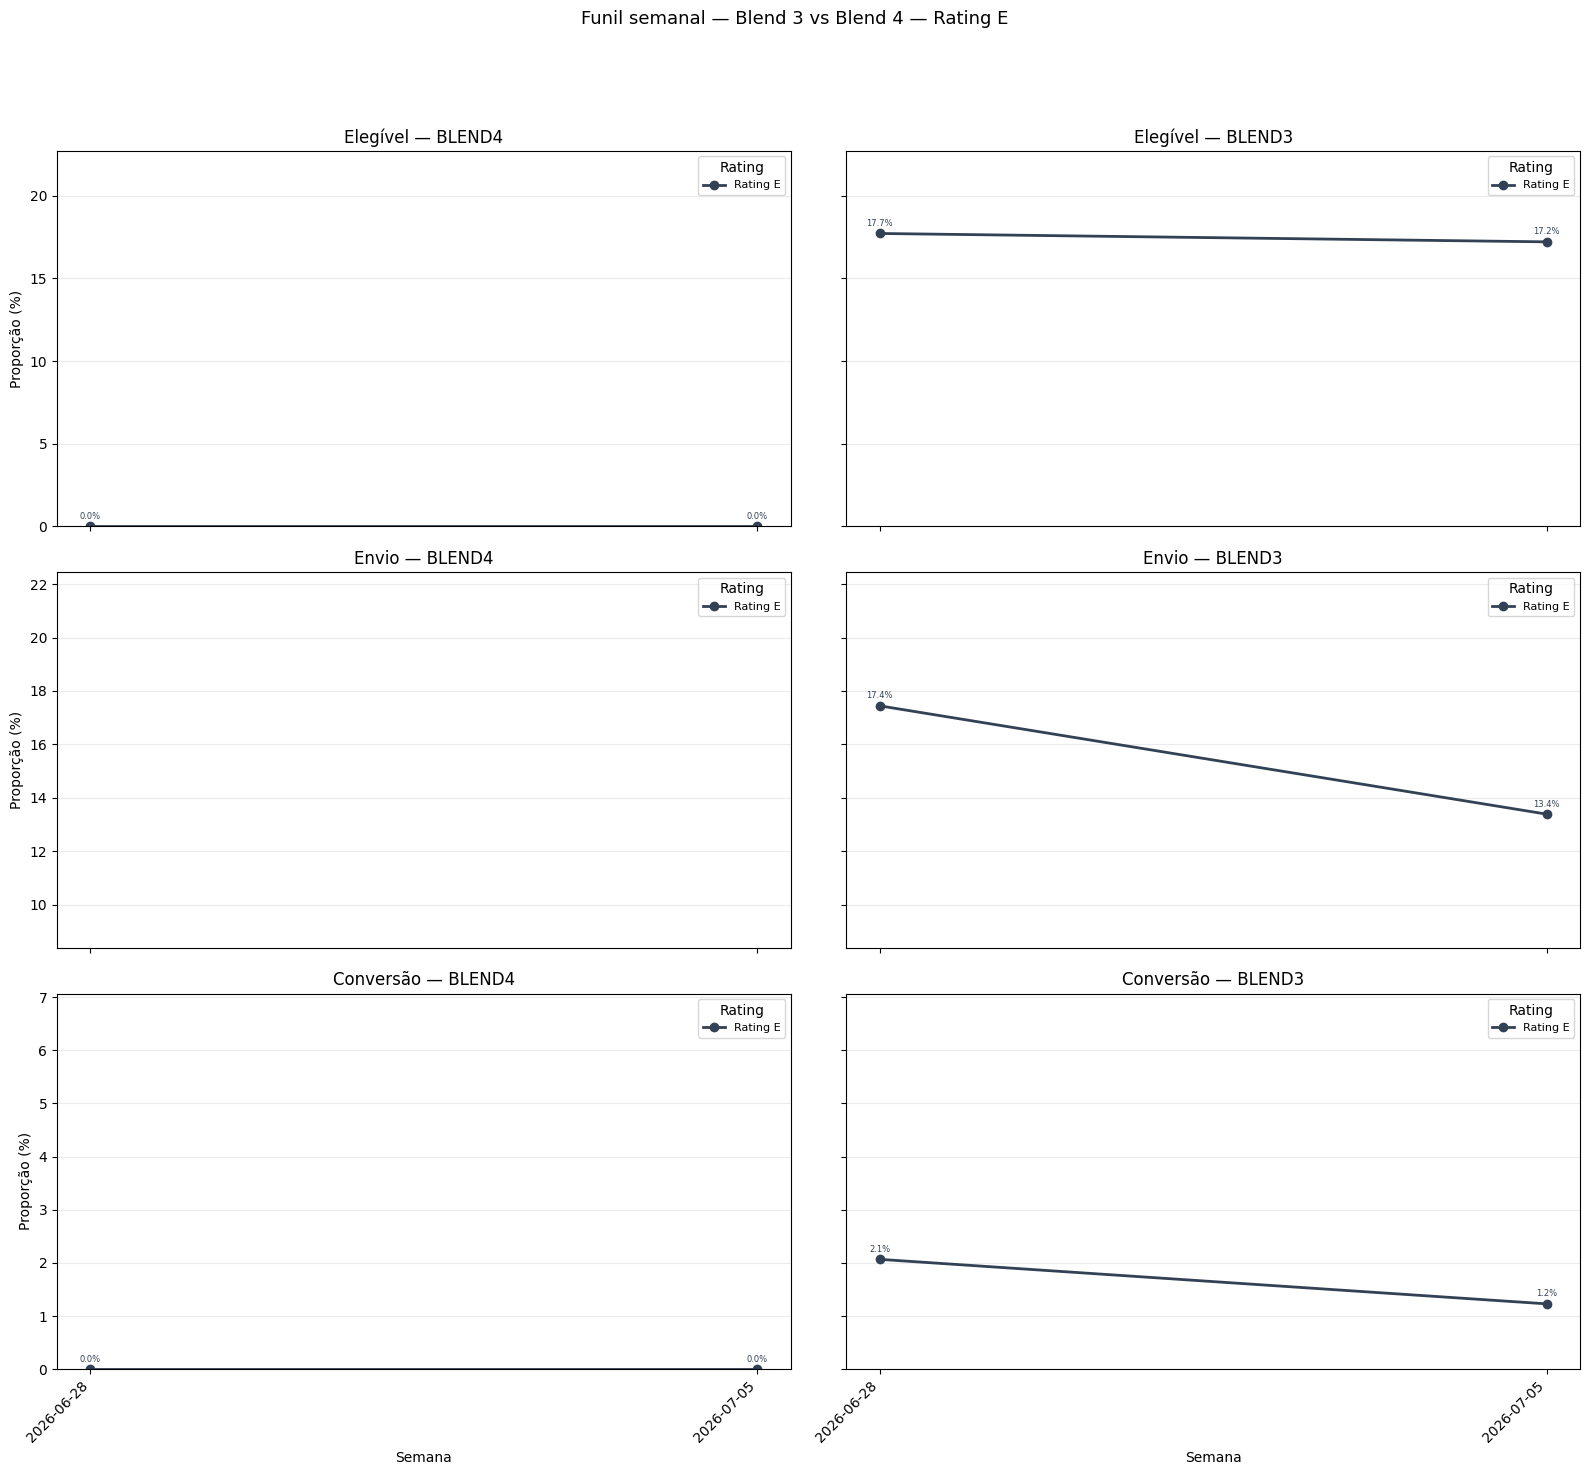

In [69]:

RATINGS_TO_PLOT = ["E"]
plot_funnel_metrics_by_rating_side_by_side(
    df_weekly,
    models=MODEL_ORDER_GRAPH,
    ratings=RATINGS_TO_PLOT,
    time_grain="week",
    model_col=MODEL_COL,
    rating_col=RATING_COL,
    # min_volume_per_model=MIN_VOLUME_WEEKLY,
    ylim=None,              # auto por linha
    auto_ylim_pad=5.0,      # margem acima/abaixo dos dados
    show_labels=True,
    suptitle="Funil semanal — Blend 3 vs Blend 4 — Rating E",
)

## Pré-Análise por Rating

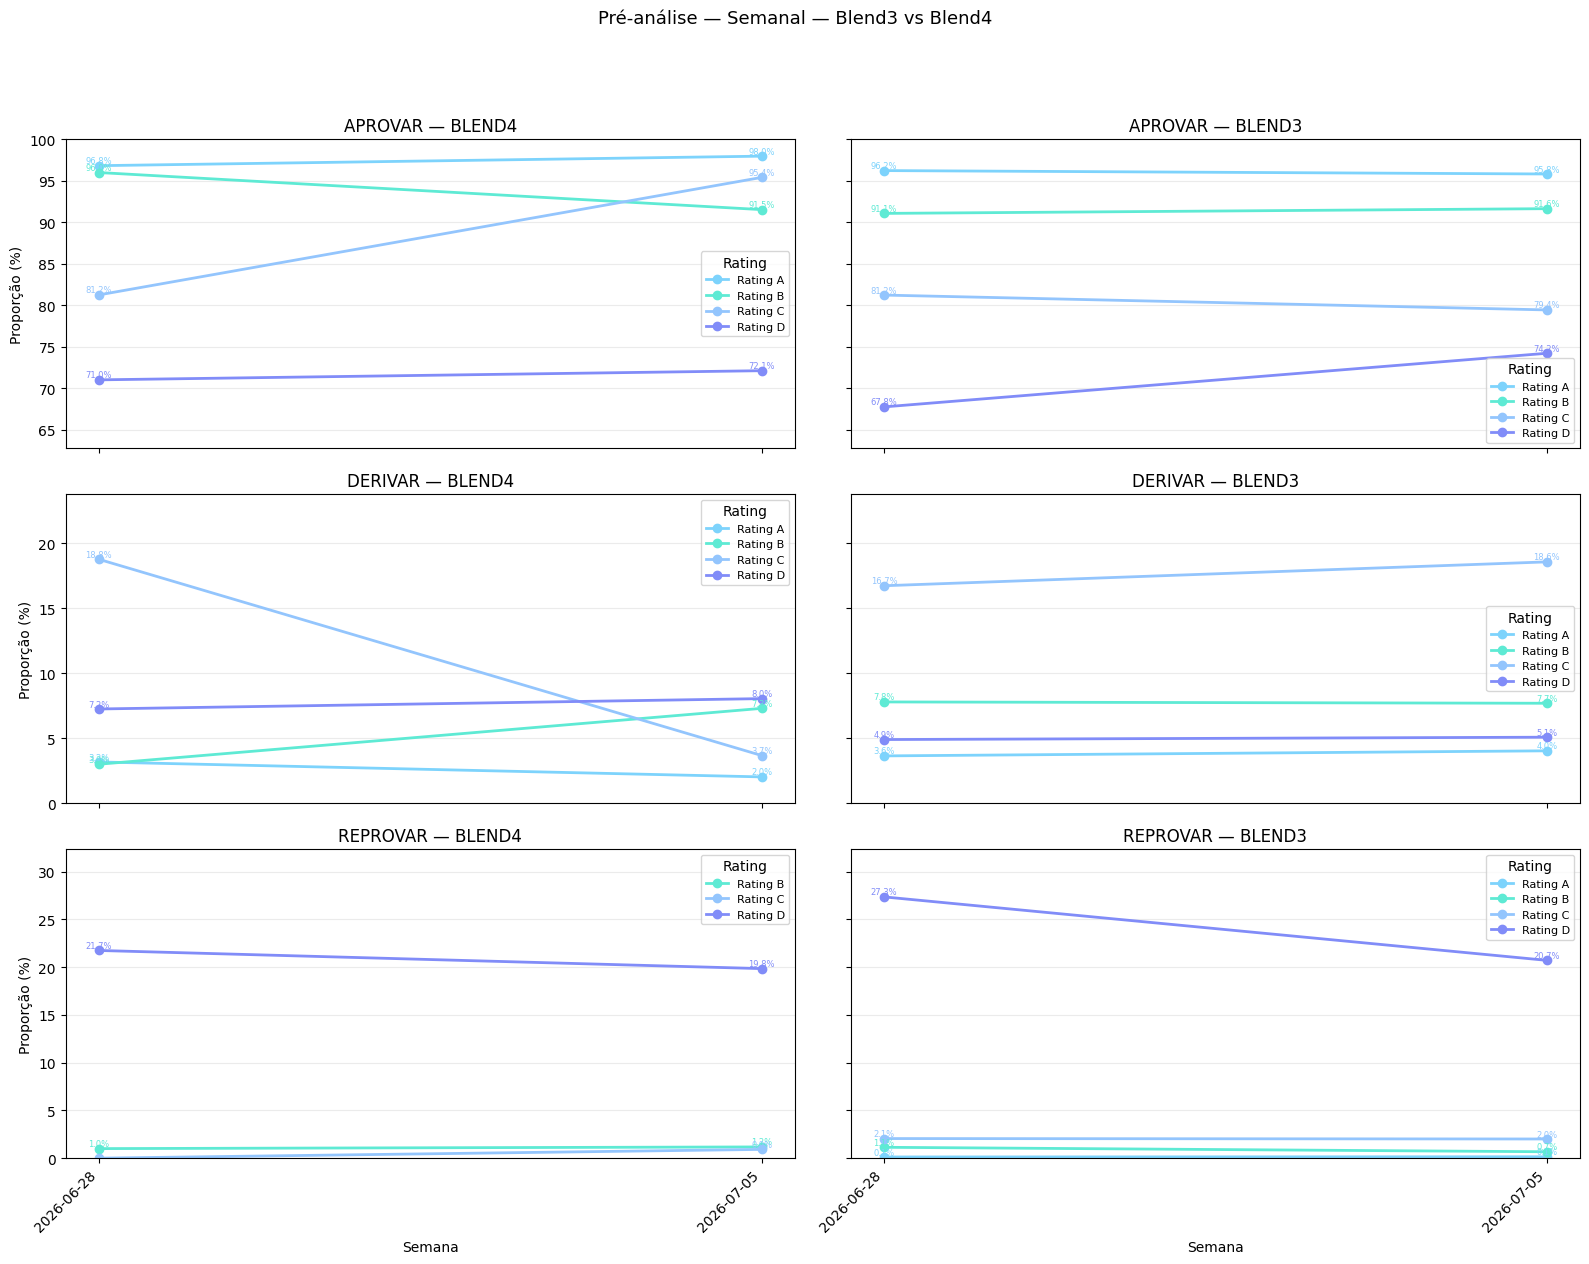

In [70]:
MIN_VOLUME_WEEKLY = 100
RATINGS_TO_PLOT = ["A", "B", "C", "D"]  # sem N/I, se preferir

plot_pre_analysis_by_rating_side_by_side(
    df_weekly,
    models=MODEL_ORDER_GRAPH,
    ratings=RATINGS_TO_PLOT,
    time_grain="week",
    model_col=MODEL_COL,
    rating_col=RATING_COL,
    rating_color_map=RATING_COLOR_MAP,
    # min_volume_per_model=MIN_VOLUME_WEEKLY,
    # ylim=None  ← padrão: auto por linha
    suptitle="Pré-análise — Semanal — Blend3 vs Blend4",
)

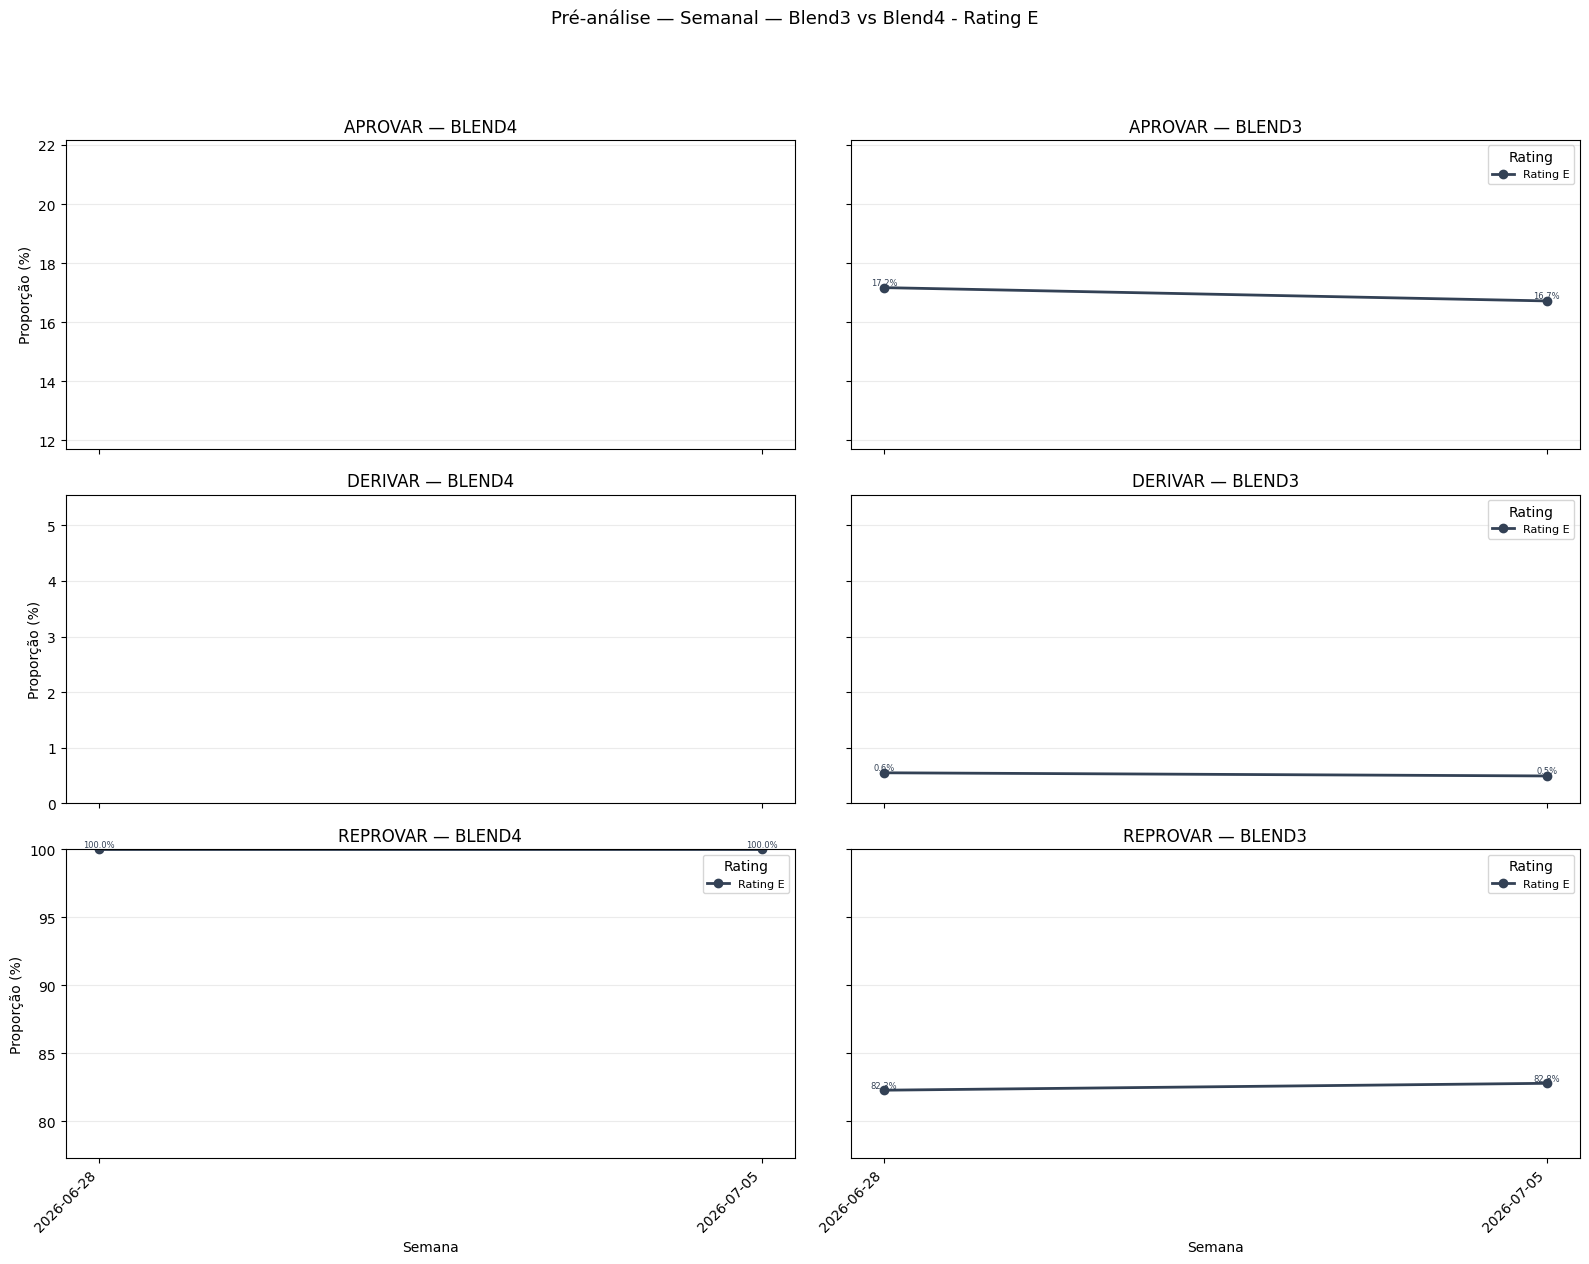

In [71]:
MIN_VOLUME_WEEKLY = 100
RATINGS_TO_PLOT = ["E"]  # sem N/I, se preferir

plot_pre_analysis_by_rating_side_by_side(
    df_weekly,
    models=MODEL_ORDER_GRAPH,
    ratings=RATINGS_TO_PLOT,
    time_grain="week",
    model_col=MODEL_COL,
    rating_col=RATING_COL,
    rating_color_map=RATING_COLOR_MAP,
    # min_volume_per_model=MIN_VOLUME_WEEKLY,
    # ylim=None  ← padrão: auto por linha
    suptitle="Pré-análise — Semanal — Blend3 vs Blend4 - Rating E",
)

## Salvar HTML

In [72]:
# rates = compute_blend_funnel_rates(df_weekly_prod, time_grain="week")
# plot_blend_funnel_with_volume(
#     rates,
#     title="Funil — Produção (Semana)",
#     xlabel="Semana",
#     rate_columns=BLEND_FUNNEL_METRICS,
#     ylim=(0, 100),
# )
# display(rates.round(1))

In [73]:
from build_report_html import export_notebook_report

report_path = export_notebook_report(
    "02.Monitoramento_Funil_Blend4.ipynb",
    title="Monitoramento Funil Blend4",
)
print(f"Report generated: {report_path}")


Report generated: /Users/lucas.nascimento/Monitoramento_Modelos/02.Monitoramento_Funil_Blend4_report.html
